# Custom Dropout and Custom Regularization

## Assignment Coverage
This notebook covers **Part 1 (g)** of the assignment:
- **Custom Dropout** - Implementing custom dropout variants (Alpha Dropout, Spatial Dropout, Concrete Dropout)
- **Custom Regularization** - Creating custom kernel, bias, and activity regularizers

Both techniques implemented in **TensorFlow/Keras** and **PyTorch** with practical examples.

**Dataset**: Fashion MNIST

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

In [2]:
# Load Fashion MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0
X_train_flat = X_train.reshape(-1, 784).astype('float32')
X_test_flat = X_test.reshape(-1, 784).astype('float32')

# Small subset for faster training
X_train_small, y_train_small = X_train_flat[:5000], y_train[:5000]

# PyTorch data
train_ds = TensorDataset(torch.tensor(X_train_small), torch.tensor(y_train_small, dtype=torch.long))
test_ds = TensorDataset(torch.tensor(X_test_flat), torch.tensor(y_test, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


---
## 1. Custom Dropout Implementations

### 1.1 TensorFlow Custom Dropout Layers

In [3]:
class MCAlphaDropout(keras.layers.Layer):
    """Alpha Dropout for SELU networks with MC inference support.
    Maintains self-normalizing property by using specific noise distribution.
    """
    def __init__(self, rate=0.5, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate
        # Alpha dropout parameters for SELU
        self.alpha = 1.6732632423543772848170429916717
        self.scale = 1.0507009873554804934193349852946

    def call(self, inputs, training=None):
        if training is None:
            training = True  # Always dropout for MC inference

        if not training:
            return inputs

        # Alpha dropout preserves mean and variance
        alpha_p = -self.alpha * self.scale
        keep_prob = 1.0 - self.rate

        # Compute affine transformation parameters
        a = (keep_prob + keep_prob * (1 - keep_prob) * alpha_p ** 2) ** -0.5
        b = -a * alpha_p * (1 - keep_prob)

        # Create dropout mask
        mask = tf.random.uniform(tf.shape(inputs)) > self.rate
        mask = tf.cast(mask, inputs.dtype)

        # Apply alpha dropout
        outputs = inputs * mask + alpha_p * (1 - mask)
        return a * outputs + b

    def get_config(self):
        config = super().get_config()
        config.update({'rate': self.rate})
        return config

In [4]:
class GaussianDropout(keras.layers.Layer):
    """Multiplicative Gaussian noise dropout.
    Multiplies inputs by N(1, sqrt(rate/(1-rate))).
    """
    def __init__(self, rate=0.5, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate

    def call(self, inputs, training=None):
        if training:
            stddev = np.sqrt(self.rate / (1.0 - self.rate))
            noise = tf.random.normal(tf.shape(inputs), mean=1.0, stddev=stddev)
            return inputs * noise
        return inputs

In [5]:
class ScheduledDropout(keras.layers.Layer):
    """Dropout with rate that changes during training.
    Starts low and increases to target rate.
    """
    def __init__(self, target_rate=0.5, warmup_steps=1000, **kwargs):
        super().__init__(**kwargs)
        self.target_rate = target_rate
        self.warmup_steps = warmup_steps
        self.step_counter = tf.Variable(0, trainable=False, dtype=tf.int64)

    def call(self, inputs, training=None):
        if training:
            self.step_counter.assign_add(1)
            # Linear warmup of dropout rate
            progress = tf.minimum(tf.cast(self.step_counter, tf.float32) / self.warmup_steps, 1.0)
            current_rate = self.target_rate * progress

            mask = tf.random.uniform(tf.shape(inputs)) > current_rate
            return inputs * tf.cast(mask, inputs.dtype) / (1.0 - current_rate + 1e-7)
        return inputs

In [6]:
# Test custom dropout layers
model_alpha = keras.Sequential([
    keras.layers.Dense(256, activation='selu', kernel_initializer='lecun_normal', input_shape=(784,)),
    MCAlphaDropout(0.3),
    keras.layers.Dense(128, activation='selu', kernel_initializer='lecun_normal'),
    MCAlphaDropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

model_alpha.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_alpha.fit(X_train_small, y_train_small, epochs=15, validation_split=0.1, verbose=0)
print(f"MC Alpha Dropout: Test Acc = {model_alpha.evaluate(X_test_flat, y_test, verbose=0)[1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MC Alpha Dropout: Test Acc = 0.8353


In [7]:
model_gaussian = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(784,)),
    GaussianDropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    GaussianDropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

model_gaussian.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_gaussian.fit(X_train_small, y_train_small, epochs=15, validation_split=0.1, verbose=0)
print(f"Gaussian Dropout: Test Acc = {model_gaussian.evaluate(X_test_flat, y_test, verbose=0)[1]:.4f}")

Gaussian Dropout: Test Acc = 0.8367


### 1.2 PyTorch Custom Dropout Layers

In [8]:
class AlphaDropoutPT(nn.Module):
    """Alpha Dropout for SELU networks in PyTorch."""
    def __init__(self, rate=0.5):
        super().__init__()
        self.rate = rate
        self.alpha = 1.6732632423543772848170429916717
        self.scale = 1.0507009873554804934193349852946

    def forward(self, x):
        if not self.training:
            return x

        alpha_p = -self.alpha * self.scale
        keep_prob = 1.0 - self.rate

        a = (keep_prob + keep_prob * (1 - keep_prob) * alpha_p ** 2) ** -0.5
        b = -a * alpha_p * (1 - keep_prob)

        mask = (torch.rand_like(x) > self.rate).float()
        return a * (x * mask + alpha_p * (1 - mask)) + b

In [9]:
class GaussianDropoutPT(nn.Module):
    """Multiplicative Gaussian noise dropout."""
    def __init__(self, rate=0.5):
        super().__init__()
        self.rate = rate

    def forward(self, x):
        if self.training:
            stddev = np.sqrt(self.rate / (1.0 - self.rate))
            noise = torch.randn_like(x) * stddev + 1.0
            return x * noise
        return x

In [10]:
class VariationalDropoutPT(nn.Module):
    """Variational Dropout with learned dropout rate per unit."""
    def __init__(self, input_dim, initial_rate=0.5):
        super().__init__()
        # Learnable log-alpha parameter for each input dimension
        init_log_alpha = np.log(initial_rate / (1 - initial_rate))
        self.log_alpha = nn.Parameter(torch.full((input_dim,), init_log_alpha))

    def forward(self, x):
        if self.training:
            alpha = torch.sigmoid(self.log_alpha)
            noise = torch.randn_like(x)
            return x + x * alpha * noise
        return x

    def kl_loss(self):
        """KL divergence term for variational inference."""
        alpha = torch.sigmoid(self.log_alpha)
        return -0.5 * torch.sum(torch.log(alpha + 1e-8))

In [11]:
class MLPCustomDropoutPT(nn.Module):
    def __init__(self, dropout_class, dropout_rate=0.3):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.drop1 = dropout_class(dropout_rate)
        self.drop2 = dropout_class(dropout_rate)

    def forward(self, x):
        x = self.drop1(torch.relu(self.fc1(x)))
        x = self.drop2(torch.relu(self.fc2(x)))
        return self.fc3(x)

In [12]:
def train_pytorch(model, epochs=15):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())

    for _ in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

    model.eval()
    correct = sum((model(X).argmax(1) == y).sum().item() for X, y in test_loader)
    return correct / len(test_ds)

In [13]:
# Test PyTorch custom dropouts
for name, dropout_cls in [('Alpha', AlphaDropoutPT), ('Gaussian', GaussianDropoutPT)]:
    torch.manual_seed(42)
    model = MLPCustomDropoutPT(dropout_cls)
    acc = train_pytorch(model)
    print(f"PyTorch {name} Dropout: Test Acc = {acc:.4f}")

PyTorch Alpha Dropout: Test Acc = 0.8065
PyTorch Gaussian Dropout: Test Acc = 0.8285


---
## 2. Custom Regularization

### 2.1 TensorFlow Custom Regularizers

In [14]:
class MyL1Regularizer(keras.regularizers.Regularizer):
    """Custom L1 regularizer with threshold.
    Only penalizes weights above a threshold for sparse but non-zero weights.
    """
    def __init__(self, factor=0.01, threshold=0.1):
        self.factor = factor
        self.threshold = threshold

    def __call__(self, weights):
        # Only penalize weights above threshold
        return self.factor * tf.reduce_sum(tf.maximum(tf.abs(weights) - self.threshold, 0))

    def get_config(self):
        return {'factor': self.factor, 'threshold': self.threshold}

In [15]:
class OrthogonalRegularizer(keras.regularizers.Regularizer):
    """Encourages weight matrices to be orthogonal.
    Penalizes W^T * W - I to maintain diverse features.
    """
    def __init__(self, factor=0.01):
        self.factor = factor

    def __call__(self, weights):
        # For 2D weight matrices
        if len(weights.shape) == 2:
            w = weights
            wt_w = tf.matmul(tf.transpose(w), w)
            identity = tf.eye(tf.shape(wt_w)[0])
            return self.factor * tf.reduce_sum(tf.square(wt_w - identity))
        return 0.0

    def get_config(self):
        return {'factor': self.factor}

In [16]:
class SparsityRegularizer(keras.regularizers.Regularizer):
    """Activity regularizer that encourages sparse activations.
    Based on KL divergence from target sparsity.
    """
    def __init__(self, target_sparsity=0.05, factor=0.1):
        self.target = target_sparsity
        self.factor = factor

    def __call__(self, activations):
        # Average activation (estimate of probability of being active)
        avg_activation = tf.reduce_mean(activations)
        # KL divergence from target sparsity
        kl = self.target * tf.math.log(self.target / (avg_activation + 1e-10)) + \
             (1 - self.target) * tf.math.log((1 - self.target) / (1 - avg_activation + 1e-10))
        return self.factor * kl

    def get_config(self):
        return {'target_sparsity': self.target, 'factor': self.factor}

In [17]:
class MaxNormConstraint(keras.constraints.Constraint):
    """Constrains weights to have max norm."""
    def __init__(self, max_value=2.0):
        self.max_value = max_value

    def __call__(self, weights):
        norms = tf.sqrt(tf.reduce_sum(tf.square(weights), axis=0, keepdims=True))
        desired = tf.clip_by_value(norms, 0, self.max_value)
        return weights * (desired / (norms + 1e-7))

    def get_config(self):
        return {'max_value': self.max_value}

In [18]:
# Test custom regularizers
model_custom_reg = keras.Sequential([
    keras.layers.Dense(256, activation='relu',
                       kernel_regularizer=MyL1Regularizer(0.001),
                       kernel_constraint=MaxNormConstraint(2.0),
                       input_shape=(784,)),
    keras.layers.Dense(128, activation='relu',
                       kernel_regularizer=OrthogonalRegularizer(0.001)),
    keras.layers.Dense(10, activation='softmax')
])

model_custom_reg.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_custom_reg.fit(X_train_small, y_train_small, epochs=15, validation_split=0.1, verbose=0)
print(f"Custom Regularizers: Test Acc = {model_custom_reg.evaluate(X_test_flat, y_test, verbose=0)[1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Custom Regularizers: Test Acc = 0.8015


First layer weight sparsity: 11.15%


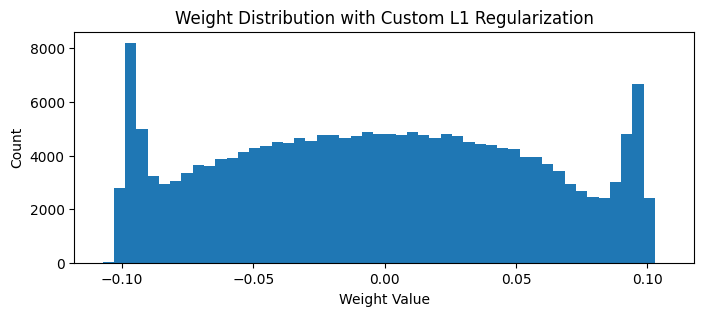

In [19]:
# Analyze weight sparsity
weights = model_custom_reg.layers[0].get_weights()[0]
sparsity = np.mean(np.abs(weights) < 0.01)
print(f"First layer weight sparsity: {sparsity:.2%}")

plt.figure(figsize=(8, 3))
plt.hist(weights.flatten(), bins=50)
plt.title('Weight Distribution with Custom L1 Regularization')
plt.xlabel('Weight Value'); plt.ylabel('Count')
plt.show()

### 2.2 PyTorch Custom Regularizers

In [20]:
def l1_threshold_regularizer(model, factor=0.001, threshold=0.1):
    """L1 regularization only for weights above threshold."""
    reg_loss = 0
    for param in model.parameters():
        reg_loss += torch.sum(torch.clamp(torch.abs(param) - threshold, min=0))
    return factor * reg_loss

def orthogonal_regularizer(model, factor=0.001):
    """Encourages orthogonal weight matrices."""
    reg_loss = 0
    for name, param in model.named_parameters():
        if 'weight' in name and len(param.shape) == 2:
            wt_w = torch.mm(param.t(), param)
            identity = torch.eye(wt_w.shape[0], device=param.device)
            reg_loss += torch.sum((wt_w - identity) ** 2)
    return factor * reg_loss

def elastic_net_regularizer(model, l1_factor=0.001, l2_factor=0.001):
    """Combined L1 and L2 regularization."""
    l1_loss = sum(torch.sum(torch.abs(p)) for p in model.parameters())
    l2_loss = sum(torch.sum(p ** 2) for p in model.parameters())
    return l1_factor * l1_loss + l2_factor * l2_loss

In [21]:
class MaxNormLinear(nn.Module):
    """Linear layer with max norm constraint on weights."""
    def __init__(self, in_features, out_features, max_norm=2.0):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.max_norm = max_norm

    def forward(self, x):
        # Apply max norm constraint
        with torch.no_grad():
            norms = self.linear.weight.norm(dim=1, keepdim=True)
            scale = torch.clamp(self.max_norm / norms, max=1.0)
            self.linear.weight.mul_(scale)
        return self.linear(x)

In [22]:
class MLPCustomRegPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = MaxNormLinear(784, 256, max_norm=2.0)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [23]:
def train_with_custom_reg(model, reg_fn, epochs=15):
    """Training with custom regularization function."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())

    for _ in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)

            # Add custom regularization
            if reg_fn:
                loss += reg_fn(model)

            loss.backward()
            optimizer.step()

    model.eval()
    correct = sum((model(X).argmax(1) == y).sum().item() for X, y in test_loader)
    return correct / len(test_ds)

In [24]:
# Test PyTorch custom regularizers
torch.manual_seed(42)
model_pt = MLPCustomRegPT()
acc = train_with_custom_reg(model_pt, lambda m: orthogonal_regularizer(m, 0.0001))
print(f"PyTorch Orthogonal Regularizer: Test Acc = {acc:.4f}")

torch.manual_seed(42)
model_pt2 = MLPCustomRegPT()
acc = train_with_custom_reg(model_pt2, lambda m: elastic_net_regularizer(m, 0.0001, 0.0001))
print(f"PyTorch Elastic Net: Test Acc = {acc:.4f}")

PyTorch Orthogonal Regularizer: Test Acc = 0.8321
PyTorch Elastic Net: Test Acc = 0.8061


---
## 3. Combined Custom Dropout + Regularization

In [25]:
# TensorFlow combined model
model_combined = keras.Sequential([
    keras.layers.Dense(256, activation='selu',
                       kernel_initializer='lecun_normal',
                       kernel_regularizer=MyL1Regularizer(0.0005),
                       kernel_constraint=MaxNormConstraint(2.0),
                       input_shape=(784,)),
    MCAlphaDropout(0.2),
    keras.layers.Dense(128, activation='selu',
                       kernel_initializer='lecun_normal',
                       kernel_regularizer=OrthogonalRegularizer(0.0005)),
    MCAlphaDropout(0.2),
    keras.layers.Dense(10, activation='softmax')
])

model_combined.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_combined.fit(X_train_small, y_train_small, epochs=20, validation_split=0.1, verbose=0)
print(f"Combined (TF): Test Acc = {model_combined.evaluate(X_test_flat, y_test, verbose=0)[1]:.4f}")

Combined (TF): Test Acc = 0.8273


In [26]:
# PyTorch combined model
class MLPCombinedPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = MaxNormLinear(784, 256)
        self.drop1 = AlphaDropoutPT(0.2)
        self.fc2 = nn.Linear(256, 128)
        self.drop2 = AlphaDropoutPT(0.2)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.drop1(torch.selu(self.fc1(x)))
        x = self.drop2(torch.selu(self.fc2(x)))
        return self.fc3(x)

torch.manual_seed(42)
model_combined_pt = MLPCombinedPT()
acc = train_with_custom_reg(model_combined_pt, lambda m: orthogonal_regularizer(m, 0.0001), epochs=20)
print(f"Combined (PyTorch): Test Acc = {acc:.4f}")

Combined (PyTorch): Test Acc = 0.8159


---
## Summary

### Custom Dropout Variants

| Variant | Use Case |
|---------|----------|
| **Alpha Dropout** | SELU networks (self-normalizing) |
| **Gaussian Dropout** | Continuous noise alternative |
| **Variational Dropout** | Bayesian inference, learned rates |
| **Scheduled Dropout** | Gradual regularization increase |

### Custom Regularizers

| Regularizer | Purpose |
|-------------|--------|
| **Threshold L1** | Sparse but non-trivial weights |
| **Orthogonal** | Decorrelated features |
| **Sparsity (Activity)** | Sparse activations |
| **Max Norm** | Bounded weight magnitudes |